# MINTERPY/n-dimensional fitting for PA sn2CO2 using PCO sn2CO2 fragmentation data as template

In [1]:
# basic python packages
import numpy as np
import pandas as pd

# specific python packages
import minterpy as mp
import cvxpy as cp
# added by Damar for handling equations
import sympy as sp

# visualisation tools
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector
from minterpy.core.utils import get_exponent_matrix
import matplotlib.patches as patches

# others
import minterpy_functions as mf
import pickle

## Import of required data

### Import and conversion of PE sn1CO2 fragmentation data

In [2]:
# Read PCsym data
data  = pd.read_csv(r"./frag_data/220614_PA_sym-sn1-sn2_CO2.csv")

# get sn2 norm_intensity and _var averaged
cols = ['FA_C_y', 'FA_DB_y', 'FA_iso_y', 'sn_y', 'CE']
intensity = data[(data['sn_x'] == 0) & (data['sn_y'] == 1)].groupby(by=cols)['norm_Intensity']
intensity_mean = intensity.mean()

intensity_var = data[(data['sn_x'] == 0) & (data['sn_y'] == 1)].groupby(by=cols)['norm_Intensity_var']
intensity_var_mean = intensity_var.mean()

# df combining the results
df = pd.concat([intensity_mean, intensity_var_mean], axis=1).reset_index()

# renaming of columns
df.columns = ['FA_C', 'FA_DB', 'FA_iso', 'sn_x', 'CE', 'norm_Intensity', 'norm_Intensity_var']

# format for Minterpy
sample_points = df[['CE', 'FA_C', 'FA_DB', 'FA_iso']].to_numpy()
function_vals = df['norm_Intensity'].to_numpy()
# weight_vals = df['norm_Intensity_var'].to_numpy()

print(f"No. of data points in SN2 = {len(function_vals)}")

No. of data points in SN2 = 83


### Visualizing dataset

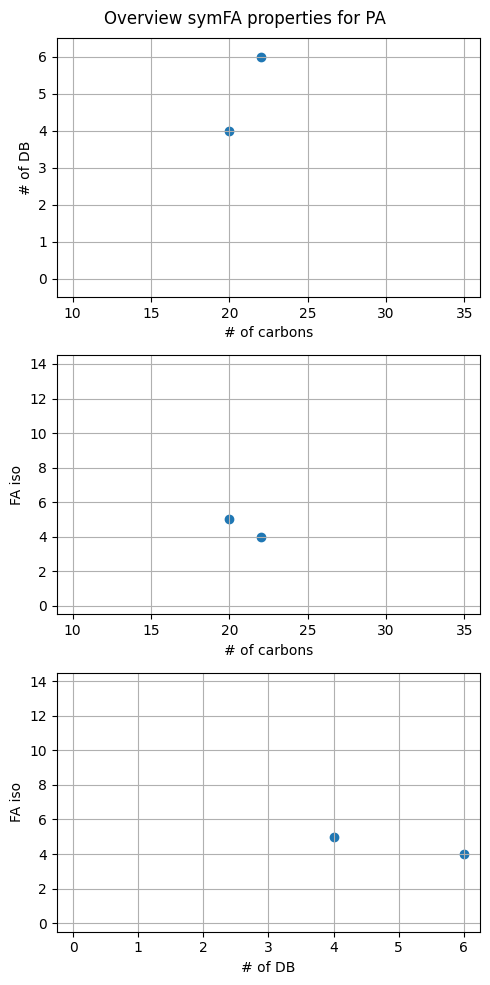

In [3]:
## get dataframe with needed properties
overview_df = df[['FA_C', 'FA_DB', 'FA_iso']].drop_duplicates()

fig, ax = plt.subplots(3,1, figsize=(5,10))

fig.suptitle('Overview symFA properties for PA')

# plot number of carbons vs number of DB
ax = plt.subplot(3,1,1)
plt.scatter(overview_df.FA_C, overview_df.FA_DB)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,6.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('# of DB')
ax.grid(which='both')

# plot number of carbons vs DB position
ax = plt.subplot(3,1,2)
plt.scatter(overview_df.FA_C, overview_df.FA_iso)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('FA iso')
ax.grid(which='both')

# plot number of DB vs DB position
ax = plt.subplot(3,1,3)
plt.scatter(overview_df.FA_DB, overview_df.FA_iso)
ax.set_xlim(-0.25,6.25)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of DB')
ax.set_ylabel('FA iso')
ax.grid(which='both')

plt.tight_layout()
plt.show()

## Import of template PCO data

In [4]:
df_pco = pd.read_csv(r"./frag_data/211004_PCO_sn2CO2.csv")

df_pco['CE'] = (1.05*df_pco['CE'] - 1)

cols = ['CE', 'FA_C', 'FA_DB', 'FA_iso']

sample_points_pco = df_pco[cols].to_numpy()
function_vals_pco = df_pco['norm_Intensity'].to_numpy()

## MINTERPY/n-dimensional fitting of scaled PCO FA fragment data

PA sn2FA dataset is used for training the polynomial model. For this, the PCO dataset is scaled to match PA and used for fitting with Minterpy.

In [5]:
# Reorganize data for fitting
size_data = function_vals.shape[0] # class of interest
size_pco_data = function_vals_pco.shape[0] # template PCO

size_train_data_wpco = size_data + size_pco_data # total size

train_sample_points = np.vstack([sample_points, sample_points_pco])
train_function_vals = np.zeros(size_train_data_wpco)

# populate train_function_vals with values
train_function_vals[:size_data] = function_vals
# scaling of PCO dataset
scaled_pco_function_vals = function_vals_pco/np.max(function_vals_pco) * np.max(function_vals)

train_function_vals[size_data:] = scaled_pco_function_vals

In [6]:
sparse_poly_model = mf.lasso_fit_data(train_sample_points,
                                        train_function_vals,
                                        poly_degree_along=[8,2,2,1], 
                                        weighted=True)

c:\Users\schuhmann\AppData\Local\Programs\Python\Python312\Lib\site-packages\minterpy\schemes\barycentric\operators.py:47: UserWarning: building a full transformation matrix from a barycentric transformation. this is inefficient.
  warn(


Optimizer result : 23.728692486393676


L_inf error of fitting PCO + dataset of interest = 34.77169513227663


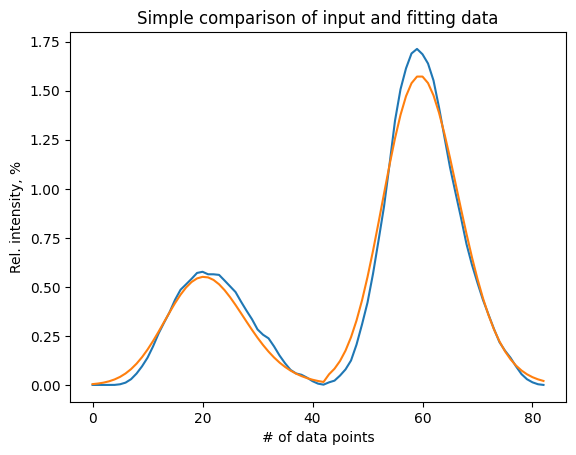

In [7]:
lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

eval_vals = mf.poly_evaluate_at(sparse_poly_model, train_sample_points, lower_bounds, upper_bounds) ## here is the calculation of fitted intensity values

abs_errs = pow(2,eval_vals[:size_data]) - train_function_vals[:size_data]
rel_errs = np.divide(abs_errs, train_function_vals[:size_data])
Linf_error = np.max(np.abs(rel_errs))
print(f"L_inf error of fitting PCO + dataset of interest = {Linf_error}")

plt.title("Simple comparison of input and fitting data")
plt.plot(train_function_vals[:size_data])
plt.plot(pow(2,eval_vals[:size_data]))
plt.xlabel("# of data points")
plt.ylabel("Rel. intensity, %")
plt.xlabel("# of data points")
plt.ylabel("Rel. intensity, %")
plt.show()

## Visualization of fitting data/results

### Fragment intensity contour plot for FA 18:x (9Z)

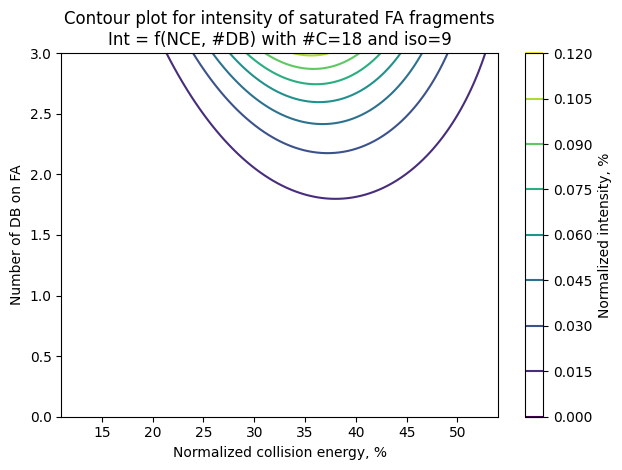

In [8]:
lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 3 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 18
fa_iso = 9

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of saturated FA fragments\nInt = f(NCE, #DB) with #C=18 and iso=9")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar().set_label('Normalized intensity, %')

plt.tight_layout()
plt.show()

### Fragment intensity contour plot for FA 20:x (5Z)

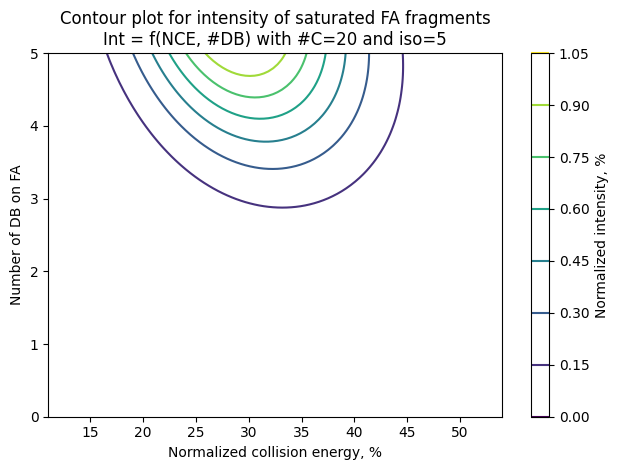

In [9]:
lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 5 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 20
fa_iso = 5

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of saturated FA fragments\nInt = f(NCE, #DB) with #C=20 and iso=5")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar().set_label('Normalized intensity, %')

plt.tight_layout()
plt.show()

#### Comparison for main FA with 0-6 DBs

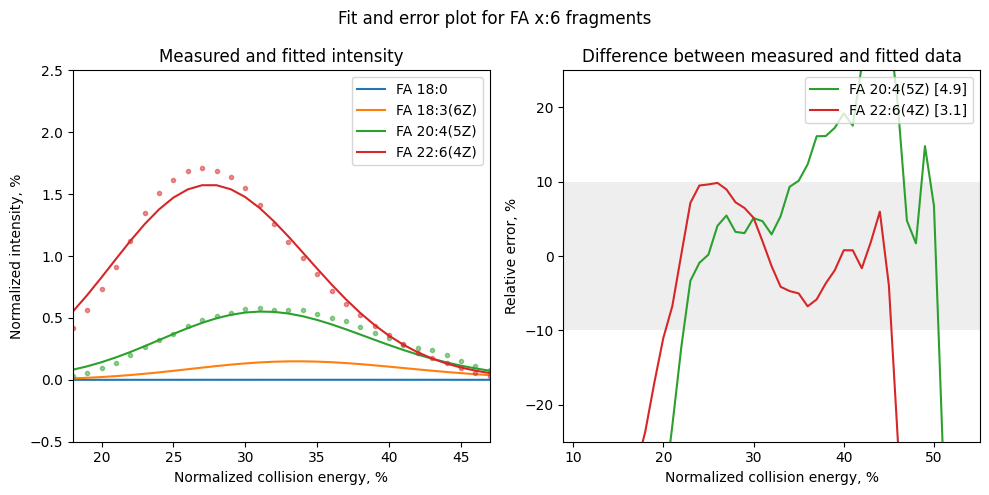

In [10]:
# color definition for plots
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'), ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'), ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

nce = [10,70] # range of nce
FA_oi = [[18, 0, 0], [18, 3, 6], [20, 4, 5], [22, 6, 4]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA x:6 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(18,47)
    ax[0].set_ylim(-0.5,2.5)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [11]:
# Transformation of NewtonPolynomials to Canonical Form
model_can = mp.get_transformation(sparse_poly_model, mp.CanonicalPolynomial)()

trimmed_coeffs = model_can.coeffs.copy()

# conditional coefficient modification, if needed
# trimmed_coeffs[np.where((trimmed_coeffs<1e0) & (trimmed_coeffs>-1e0))] = 0.0
# trimmed_coeffs = np.around(trimmed_coeffs, 2)

model_can.coeffs = trimmed_coeffs
model_eqn = mf.mp_to_sympy(model_can)

# conversion to equation
model_eqn

Poly(-6.24433343738283e-14*x_0**8 - 2.84217094304041e-14*x_0**7*x_1**2*x_2**2*x_3 + 2.13162820728032e-14*x_0**7*x_1**2*x_2**2 - 2.84217094304042e-14*x_0**7*x_1**2*x_2*x_3 - 1.42108547152022e-14*x_0**7*x_1**2*x_2 - 3.55271367880051e-15*x_0**7*x_1**2*x_3 - 1.24344978758019e-13*x_0**7*x_1**2 + 5.68434188608084e-14*x_0**7*x_1*x_2**2*x_3 - 7.10542735760103e-15*x_0**7*x_1*x_2**2 + 2.8421709430404e-14*x_0**7*x_1*x_2*x_3 - 2.8421709430404e-14*x_0**7*x_1*x_2 - 3.90798504668059e-14*x_0**7*x_1*x_3 - 3.55271367880046e-15*x_0**7*x_1 - 3.55195418981277e-14*x_0**7*x_2**2*x_3 - 1.27366891819245e-13*x_0**7*x_2**2 + 2.13162820728032e-14*x_0**7*x_2*x_3 + 2.13162820728032e-14*x_0**7*x_2 - 1.42184496050794e-14*x_0**7*x_3 - 1.13123343270511e-13*x_0**7 + 1.17683640610265e-14*x_0**6*x_1**2*x_2**2*x_3 - 1.3988810110277e-14*x_0**6*x_1**2*x_2**2 - 6.66133814775057e-16*x_0**6*x_1**2*x_2*x_3 + 1.08801856413266e-14*x_0**6*x_1**2*x_2 - 4.44089209850048e-15*x_0**6*x_1**2*x_3 - 7.99360577730057e-15*x_0**6*x_1**2 - 3.7

## Save the polynomial function as pickle

In [12]:
# write polynomial coefficients and exponents to dictionary for export
poly_info = {'coeffs': sparse_poly_model.coeffs, 'exponents': sparse_poly_model.multi_index.exponents, 'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

# Storing the polynomial object in a file
pickle.dump(poly_info, open(r'./polynomials/240925_PA_sn2CO2_poly.pkl', 'ab'))

In [13]:
poly_info

{'coeffs': array([-8.77707254e+00, -2.70673410e+00, -6.17951797e+00,  1.39814168e+00,
        -4.51194637e-13, -2.43360887e-13, -2.70006240e-13, -1.98951966e-13,
        -4.63593214e-14, -1.03103872e-02, -5.12923037e-14,  3.06421555e-14,
        -1.31450406e-13,  2.44249065e-14, -1.78523862e-13,  2.13162821e-14,
        -8.52651283e-14,  6.02572796e-01, -4.19664303e-13, -9.32587341e-14,
        -5.77315973e-13, -8.39328607e-14, -2.33590924e-13, -1.77635684e-14,
        -5.68434189e-14, -5.58824213e-01, -2.00538124e+00, -6.17284002e-14,
         4.35207426e-14, -5.77315973e-14,  1.44773082e-13, -1.06581410e-14,
         7.10542736e-14, -6.26165786e-14, -8.29336599e-14,  1.06581410e-14,
        -1.34114941e-13,  8.88178420e-15, -1.28341782e-13,  7.99360578e-15,
        -5.68434189e-14,  6.02572796e-01, -7.32747196e-15, -6.66133815e-15,
         1.59872116e-14, -2.66453526e-15,  5.37347944e-14,  1.15463195e-14,
         1.42108547e-14, -1.57665815e+00, -3.56603636e-13, -1.09245946e-13,
  

## Build CO2NL template for PA

In [14]:
CO2NLspecies = df_pco[['FA_C', 'FA_DB', 'FA_iso']].drop_duplicates().to_numpy()

In [15]:
## get template intensity data from fitting for PCO

lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

data_l = []

for i in CO2NLspecies: ## getting data for CO2NL species

    num_points_in_grid = int(upper_bounds[0] - lower_bounds[0])+1

    xvals = np.linspace(lower_bounds[0], upper_bounds[0], num_points_in_grid)

    eval_points = np.zeros((num_points_in_grid, 4))
    eval_points[:,0] = xvals ## NCE
    eval_points[:,1] = np.full((1,num_points_in_grid), i[0]) ## FA_C
    eval_points[:,2] = i[1]
    eval_points[:,3] = i[2]

    intensity = pd.DataFrame(pow(2, mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)))
    data = pd.DataFrame(eval_points)
    data_l.append(pd.concat([data, intensity], axis=1))

pasn2_template_df = pd.concat(data_l)

pasn2_template_df = pasn2_template_df.reset_index(drop=True)

pasn2_template_df.columns = ['CE', 'FA_C', 'FA_DB', 'FA_iso', 'norm_Intensity']

## Export PCO template species
pickle.dump(pasn2_template_df, open('./helper/CO2NL_PAsn2_template.pkl', 'ab'))